# Análisis Exploratorio de Datos (EDA) - EnergiAI

**Dataset Extendido** de Consumo Energético

### 1. Configuración inicial y carga de datos

In [2]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings('ignore')
plt.style.use('ggplot')
sns.set_palette("Set2")
%matplotlib inline

In [3]:
# Cargar dataset extendido y verificación inicial

DATA_PATH           = '../data/processed/dataset_extendido.csv'
OUTPUT_IMAGES_PATH  = '../images/eda_extendido/'

# Crear carpeta para imágenes si no existe
#os.makedirs(OUTPUT_IMAGES_PATH, exist_ok=True)

df_ext = pd.read_csv(DATA_PATH)

print("Dataset extendido cargado correctamente.")
print(f"Dimensiones: {df_ext.shape[0]} filas, {df_ext.shape[1]} columnas.")
print("\nPrimeras 5 filas:")
display(df_ext.head())

Dataset extendido cargado correctamente.
Dimensiones: 3000 filas, 10 columnas.

Primeras 5 filas:


,consumo_kwh,cantidad_equipos,horas_alto_consumo,tipo_inmueble,uso_horario_pico,numero_habitantes,antiguedad_inmueble,calefaccion,aire_acondicionado,categoria
0,1128,13,2,Casa,True,6,44,True,False,Moderado
1,1500,12,9,Local,True,4,46,False,True,Ineficiente
2,1348,6,6,Oficina,True,1,26,True,False,Moderado
3,241,19,10,Apartamento,False,3,11,True,False,Moderado
4,546,20,3,Apartamento,False,3,12,False,False,Eficiente


### 2. Estructura y tipos de datos

In [4]:
# Información general
df_ext.info()

<class 'pandas.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   consumo_kwh          3000 non-null   int64
 1   cantidad_equipos     3000 non-null   int64
 2   horas_alto_consumo   3000 non-null   int64
 3   tipo_inmueble        3000 non-null   str  
 4   uso_horario_pico     3000 non-null   bool 
 5   numero_habitantes    3000 non-null   int64
 6   antiguedad_inmueble  3000 non-null   int64
 7   calefaccion          3000 non-null   bool 
 8   aire_acondicionado   3000 non-null   bool 
 9   categoria            3000 non-null   str  
dtypes: bool(3), int64(5), str(2)
memory usage: 173.0 KB


In [5]:
# Resumen estadístico de variables numéricas

num_cols = ['consumo_kwh', 'cantidad_equipos', 'horas_alto_consumo', 
            'numero_habitantes', 'antiguedad_inmueble']

print("Resumen estadístico de variables numéricas:")
print("-" * 45)
display(df_ext[num_cols].describe())

Resumen estadístico de variables numéricas:
---------------------------------------------


,consumo_kwh,cantidad_equipos,horas_alto_consumo,numero_habitantes,antiguedad_inmueble
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,772.238333,13.434333,8.449333,3.474667,24.641333
std,398.397689,6.668871,4.008506,1.718044,14.781436
min,80.000000,2.000000,2.000000,1.000000,0.000000
25%,435.750000,8.000000,5.000000,2.000000,12.000000
50%,766.000000,14.000000,8.000000,3.000000,24.000000
75%,1089.000000,19.000000,12.000000,5.000000,37.000000
max,1500.000000,24.000000,15.000000,6.000000,50.000000


In [6]:
# Detección de valores atípicos (outliers) usando IQR

print("Valores atípicos por variable numérica:")
print("-" * 40)
for col in num_cols:
    Q1 = df_ext[col].quantile(0.25)
    Q3 = df_ext[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df_ext[(df_ext[col] < lower_bound) | (df_ext[col] > upper_bound)]
    print(f"{col}: {len(outliers)} valores atípicos ({len(outliers)/len(df_ext)*100:.2f}%)")

Valores atípicos por variable numérica:
----------------------------------------
consumo_kwh: 0 valores atípicos (0.00%)
cantidad_equipos: 0 valores atípicos (0.00%)
horas_alto_consumo: 0 valores atípicos (0.00%)
numero_habitantes: 0 valores atípicos (0.00%)
antiguedad_inmueble: 0 valores atípicos (0.00%)


In [7]:
# Resumen de variables categóricas

cat_cols = ['tipo_inmueble', 'uso_horario_pico', 'calefaccion', 
            'aire_acondicionado', 'categoria']

print("Resumen de variables categóricas:")
print("-" * 35)
display(df_ext[cat_cols].describe(include=['object', 'bool']))

Resumen de variables categóricas:
-----------------------------------


,tipo_inmueble,uso_horario_pico,calefaccion,aire_acondicionado,categoria
count,3000,3000,3000,3000,3000
unique,4,2,2,2,3
top,Casa,False,False,False,Moderado
freq,1179,1656,1925,1768,2202


In [8]:
# Frecuencias detalladas
for col in cat_cols:
    print(f"\n (variable) {col}:")
    print(df_ext[col].value_counts())
    print(f"   Proporciones:\n{df_ext[col].value_counts(normalize=True).round(3)}")


 (variable) tipo_inmueble:
tipo_inmueble
Casa           1179
Apartamento     903
Local           498
Oficina         420
Name: count, dtype: int64
   Proporciones:
tipo_inmueble
Casa           0.393
Apartamento    0.301
Local          0.166
Oficina        0.140
Name: proportion, dtype: float64

 (variable) uso_horario_pico:
uso_horario_pico
False    1656
True     1344
Name: count, dtype: int64
   Proporciones:
uso_horario_pico
False    0.552
True     0.448
Name: proportion, dtype: float64

 (variable) calefaccion:
calefaccion
False    1925
True     1075
Name: count, dtype: int64
   Proporciones:
calefaccion
False    0.642
True     0.358
Name: proportion, dtype: float64

 (variable) aire_acondicionado:
aire_acondicionado
False    1768
True     1232
Name: count, dtype: int64
   Proporciones:
aire_acondicionado
False    0.589
True     0.411
Name: proportion, dtype: float64

 (variable) categoria:
categoria
Moderado       2202
Ineficiente     638
Eficiente       160
Name: count, dtype: in

### 3. Análisis exploratorio univariado

In [9]:
num_cols = ['consumo_kwh', 'cantidad_equipos', 'horas_alto_consumo', 
            'numero_habitantes', 'antiguedad_inmueble']

print("Estadísticas detalladas de variables numéricas:")
print("-" * 50)
for col in num_cols:
    print(f"\n Variable: {col}:")
    print(f"   Rango: [{df_ext[col].min()}, {df_ext[col].max()}]")
    print(f"   Media: {df_ext[col].mean():.2f}")
    print(f"   Mediana: {df_ext[col].median():.2f}")
    print(f"   Desviación estándar: {df_ext[col].std():.2f}")
    print(f"   Coeficiente de variación: {(df_ext[col].std()/df_ext[col].mean())*100:.2f}%")
    print(f"   Asimetría: {df_ext[col].skew():.2f}")
    print(f"   Curtosis: {df_ext[col].kurtosis():.2f}")

Estadísticas detalladas de variables numéricas:
--------------------------------------------------

 Variable: consumo_kwh:
   Rango: [80, 1500]
   Media: 772.24
   Mediana: 766.00
   Desviación estándar: 398.40
   Coeficiente de variación: 51.59%
   Asimetría: 0.09
   Curtosis: -1.05

 Variable: cantidad_equipos:
   Rango: [2, 24]
   Media: 13.43
   Mediana: 14.00
   Desviación estándar: 6.67
   Coeficiente de variación: 49.64%
   Asimetría: -0.07
   Curtosis: -1.20

 Variable: horas_alto_consumo:
   Rango: [2, 15]
   Media: 8.45
   Mediana: 8.00
   Desviación estándar: 4.01
   Coeficiente de variación: 47.44%
   Asimetría: 0.01
   Curtosis: -1.20

 Variable: numero_habitantes:
   Rango: [1, 6]
   Media: 3.47
   Mediana: 3.00
   Desviación estándar: 1.72
   Coeficiente de variación: 49.44%
   Asimetría: 0.04
   Curtosis: -1.28

 Variable: antiguedad_inmueble:
   Rango: [0, 50]
   Media: 24.64
   Mediana: 24.00
   Desviación estándar: 14.78
   Coeficiente de variación: 59.99%
   Asimet

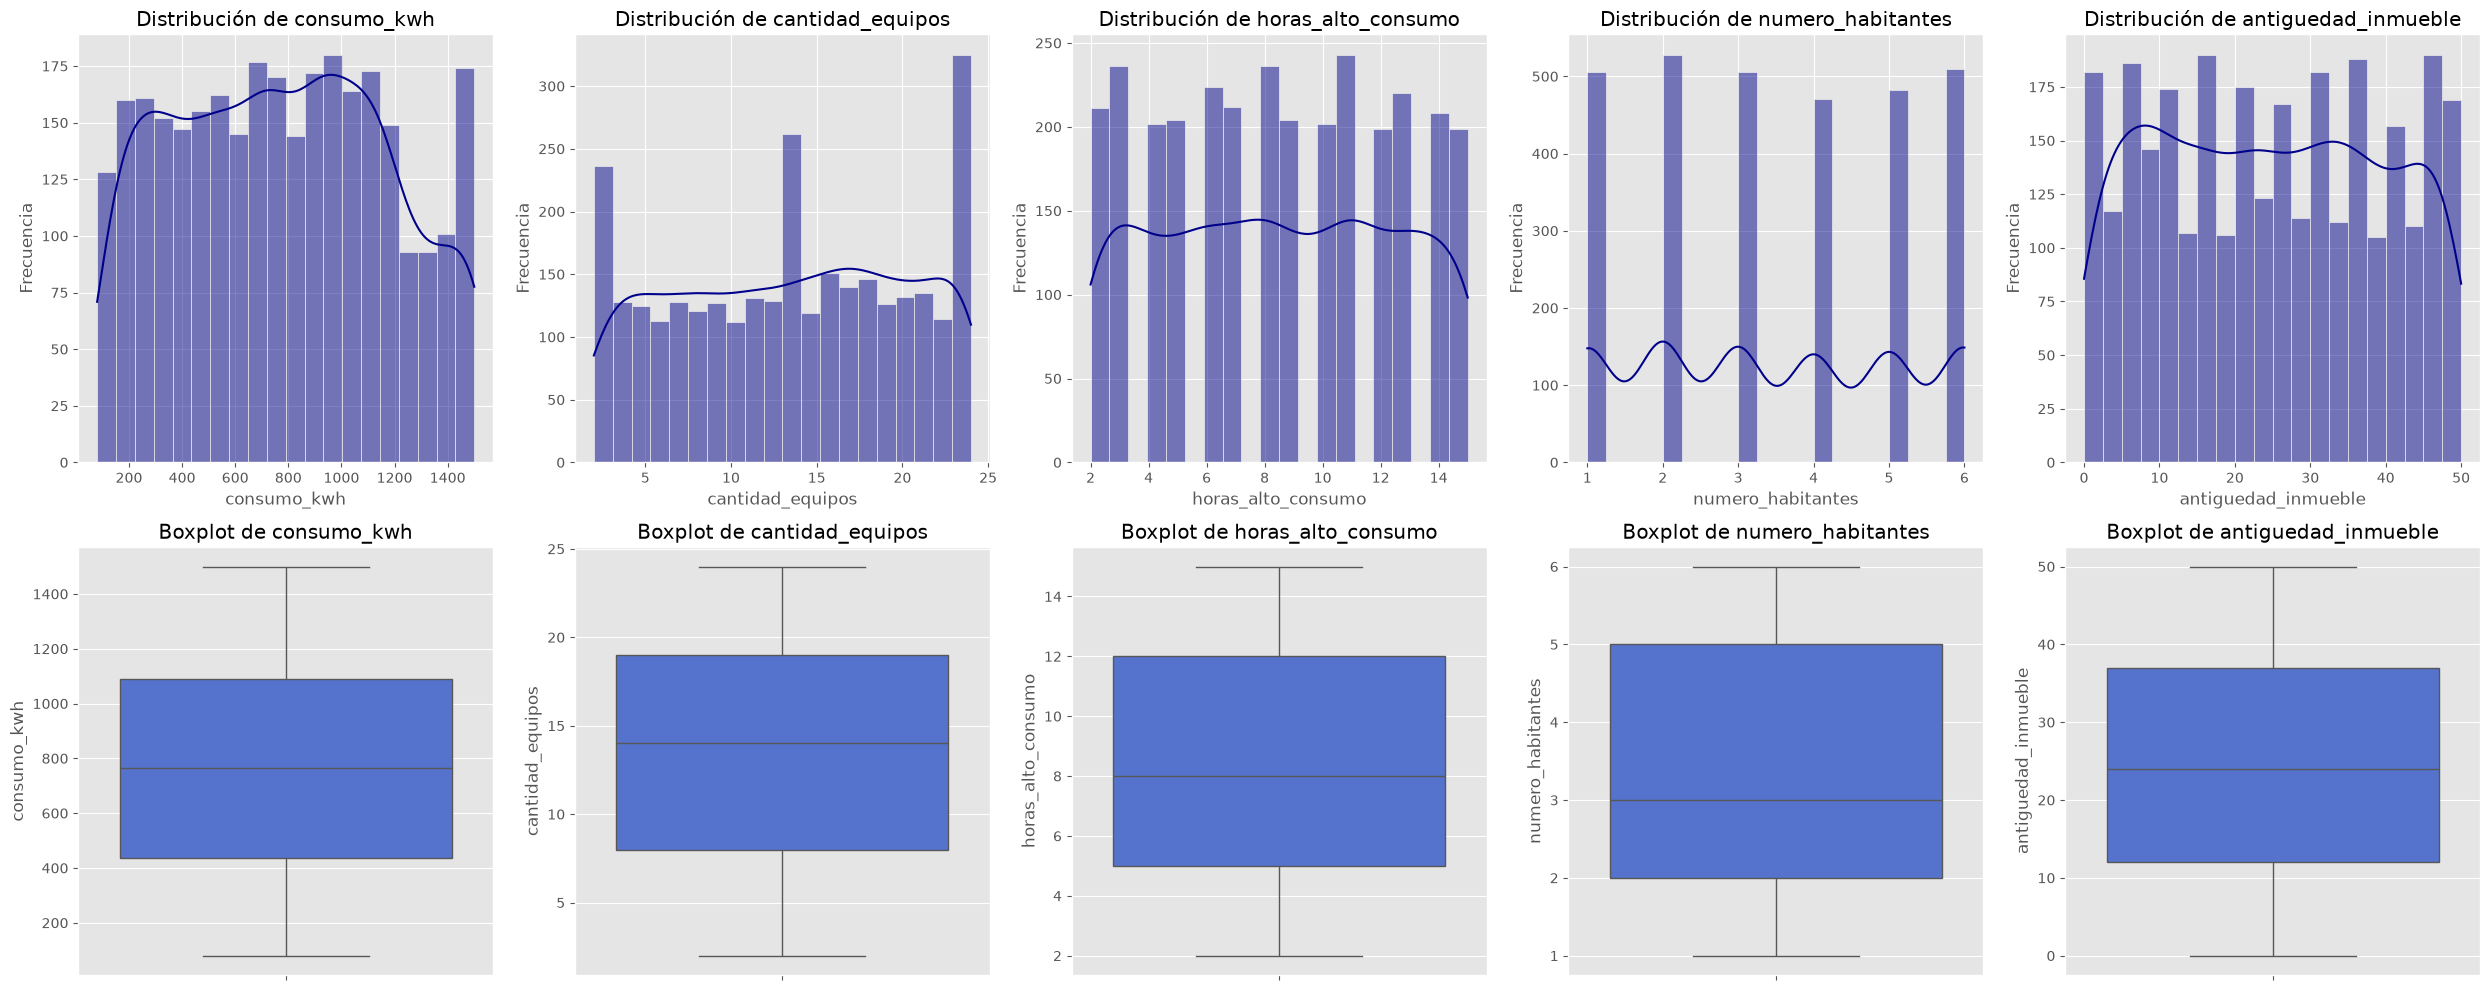

In [10]:
# Histogramas y boxplots para variables numéricas

# Ajustamos de cuadrícula según la cantidad de variables
n_vars = len(num_cols)
fig, axes = plt.subplots(2, n_vars, figsize=(5 * n_vars, 10))

# Si solo hay 1 variable, axes es un arreglo bidimensional
if n_vars == 1:
    axes = np.array([[axes[0]], [axes[1]]])

for i, col in enumerate(num_cols):
    # Histograma + KDE (Fila 0, Columna i)
    sns.histplot(df_ext[col], kde=True, ax=axes[0, i], color='darkblue', bins=20)
    axes[0, i].set_title(f'Distribución de {col}')
    axes[0, i].set_xlabel(col)
    axes[0, i].set_ylabel('Frecuencia')
    
    # Boxplot (Fila 1, Columna i)
    sns.boxplot(y=df_ext[col], ax=axes[1, i], color='royalblue')
    axes[1, i].set_title(f'Boxplot de {col}')
    axes[1, i].set_ylabel(col)

plt.tight_layout()
#plt.savefig(f'{OUTPUT_IMAGES_PATH}/univariado_categoricas_extendido.png', dpi=150, bbox_inches='tight')
plt.show()


 Variable: tipo_inmueble
------------------------------
tipo_inmueble
Casa           1179
Apartamento     903
Local           498
Oficina         420
Name: count, dtype: int64

Proporciones:
tipo_inmueble
Casa           0.393
Apartamento    0.301
Local          0.166
Oficina        0.140
Name: proportion, dtype: float64

 Variable: uso_horario_pico
------------------------------
uso_horario_pico
False    1656
True     1344
Name: count, dtype: int64

Proporciones:
uso_horario_pico
False    0.552
True     0.448
Name: proportion, dtype: float64

 Variable: calefaccion
------------------------------
calefaccion
False    1925
True     1075
Name: count, dtype: int64

Proporciones:
calefaccion
False    0.642
True     0.358
Name: proportion, dtype: float64

 Variable: aire_acondicionado
------------------------------
aire_acondicionado
False    1768
True     1232
Name: count, dtype: int64

Proporciones:
aire_acondicionado
False    0.589
True     0.411
Name: proportion, dtype: float64

 Variab

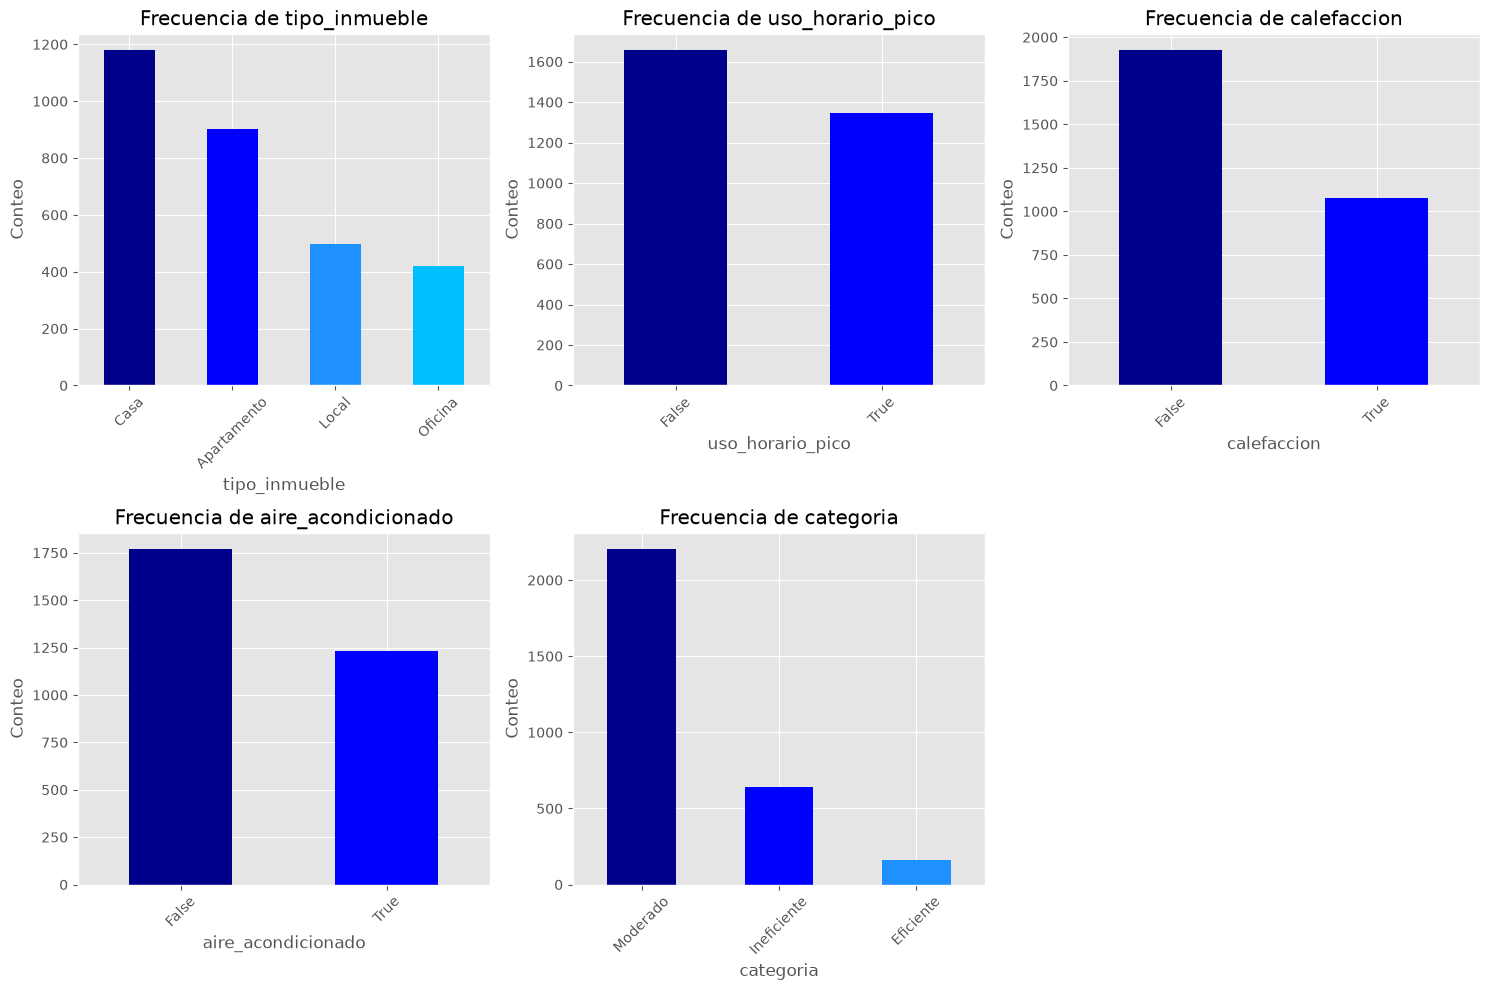

In [11]:
# Variables categóricas 

cat_cols = ['tipo_inmueble', 'uso_horario_pico', 'calefaccion', 
            'aire_acondicionado', 'categoria']

for col in cat_cols:
    print(f"\n Variable: {col}")
    print("-" * 30)
    print(df_ext[col].value_counts())
    print(f"\nProporciones:\n{df_ext[col].value_counts(normalize=True).round(3)}")

# Gráficos de barras para variables categóricas
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    df_ext[col].value_counts().plot(kind='bar', ax=axes[i], 
                                     color=['darkblue', 'blue', 'dodgerblue', 'deepskyblue', 'royalblue'])
    axes[i].set_title(f'Frecuencia de {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Conteo')
    axes[i].tick_params(axis='x', rotation=45)

# Ocultar el subplot sobrante
if len(cat_cols) < len(axes):
    for j in range(len(cat_cols), len(axes)):
        axes[j].axis('off')

plt.tight_layout()
#plt.savefig(f'{OUTPUT_IMAGES_PATH}/univariado_categoricas_extendido.png', dpi=150, bbox_inches='tight')
plt.show()

Distribución de la variable objetivo:
----------------------------------------
categoria
Moderado       2202
Ineficiente     638
Eficiente       160
Name: count, dtype: int64

Proporciones:
categoria
Moderado       0.734
Ineficiente    0.213
Eficiente      0.053
Name: proportion, dtype: float64


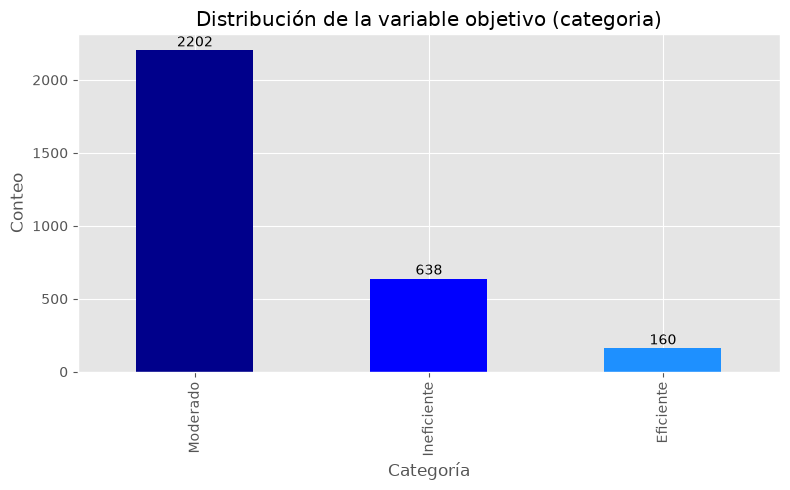

In [12]:
# Distribución de la variable objetivo

print("Distribución de la variable objetivo:")
print("-" * 40)
print(df_ext['categoria'].value_counts())
print(f"\nProporciones:\n{df_ext['categoria'].value_counts(normalize=True).round(3)}")

# Gráfico de barras con etiquetas
fig, ax = plt.subplots(figsize=(8, 5))
df_ext['categoria'].value_counts().plot(kind='bar', ax=ax, 
                                         color=['darkblue', 'blue', 'dodgerblue'])
ax.set_title('Distribución de la variable objetivo (categoria)')
ax.set_xlabel('Categoría')
ax.set_ylabel('Conteo')

for i, v in enumerate(df_ext['categoria'].value_counts()):
    ax.text(i, v + 5, str(v), ha='center', va='bottom')

plt.tight_layout()
#plt.savefig(f'{OUTPUT_IMAGES_PATH}/distribucion_categoria_extendido.png', dpi=150, bbox_inches='tight')
plt.show()

### 4. Análisis bivariado y multivariado

Matriz de correlación entre variables numéricas:
--------------------------------------------------


,consumo_kwh,cantidad_equipos,horas_alto_consumo,numero_habitantes,antiguedad_inmueble
consumo_kwh,1.000000,0.015062,0.016068,0.000783,-0.016123
cantidad_equipos,0.015062,1.000000,0.009973,0.000510,0.017425
horas_alto_consumo,0.016068,0.009973,1.000000,0.011482,-0.007949
numero_habitantes,0.000783,0.000510,0.011482,1.000000,0.021622
antiguedad_inmueble,-0.016123,0.017425,-0.007949,0.021622,1.000000


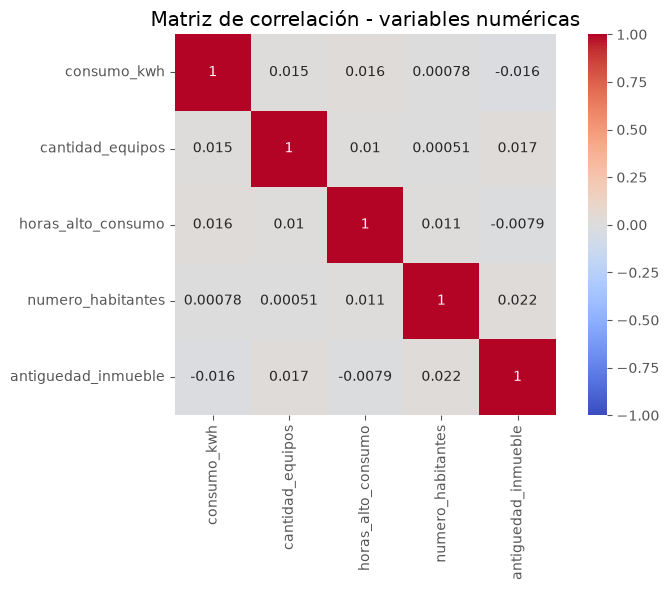

In [13]:
#  Matriz de correlación entre variables numéricas

num_cols = ['consumo_kwh', 'cantidad_equipos', 'horas_alto_consumo', 
            'numero_habitantes', 'antiguedad_inmueble']

corr_matrix = df_ext[num_cols].corr()

print("Matriz de correlación entre variables numéricas:")
print("-" * 50)
display(corr_matrix)

# Heatmap de correlación
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, square=True)
plt.title('Matriz de correlación - variables numéricas')
plt.tight_layout()
#plt.savefig(f'{OUTPUT_IMAGES_PATH}/matriz_correlacion_extendido.png', dpi=150, bbox_inches='tight')
plt.show()

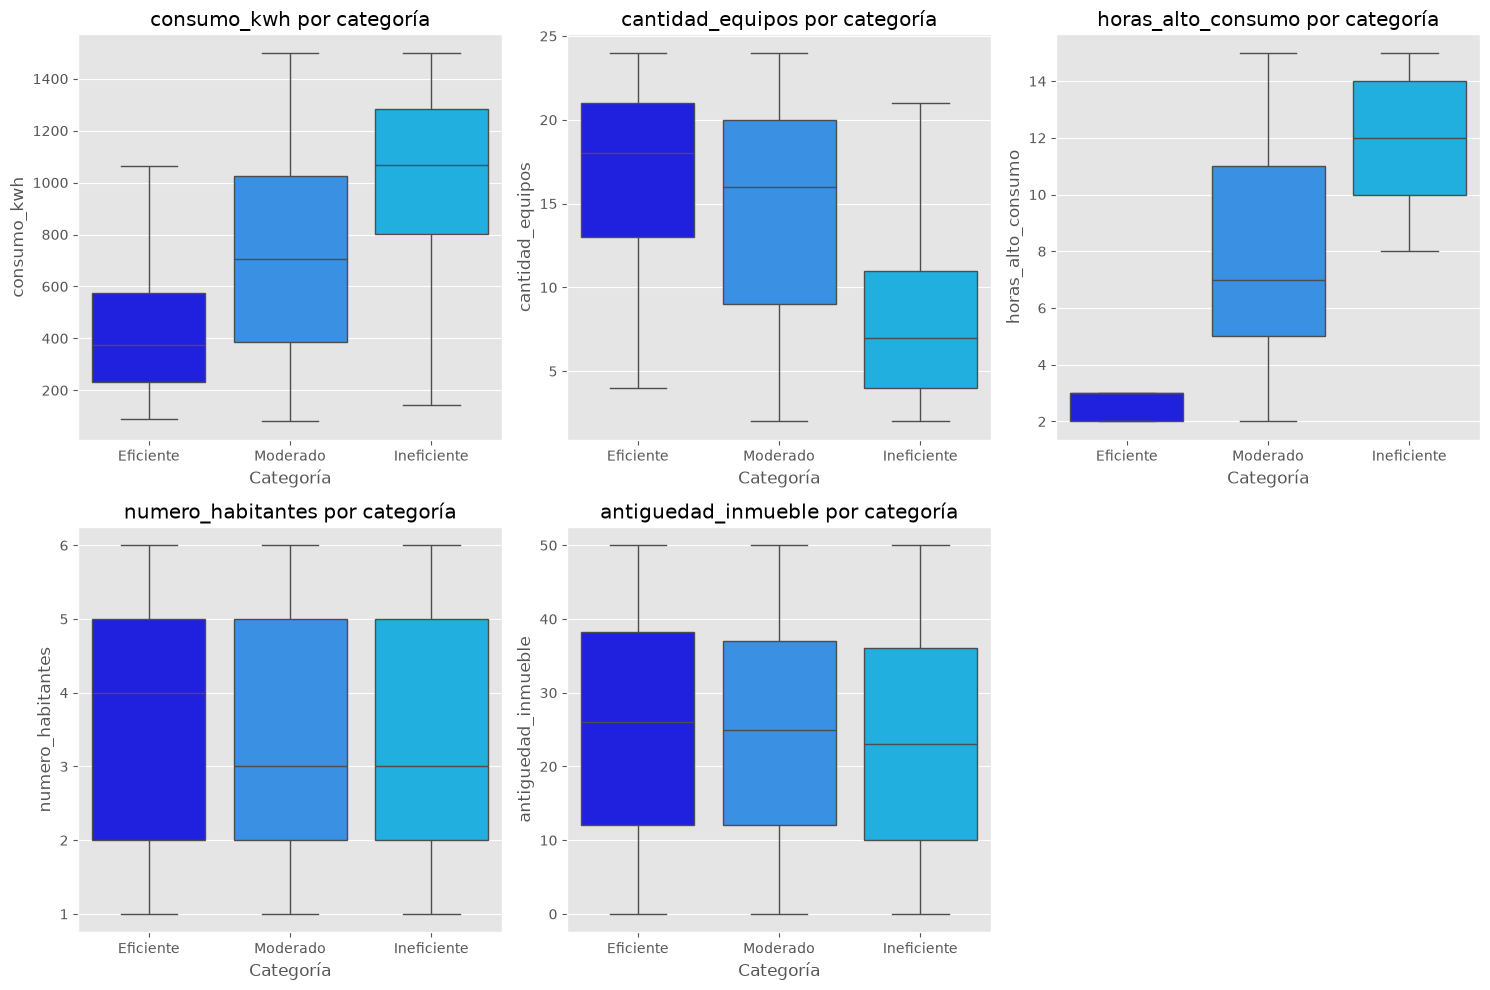

In [14]:
# Boxplots de variables numéricas por categoría

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(data=df_ext, x='categoria', y=col, ax=axes[i], 
                order=['Eficiente', 'Moderado', 'Ineficiente'], palette=['blue', 'dodgerblue', 'deepskyblue'])
    axes[i].set_title(f'{col} por categoría')
    axes[i].set_xlabel('Categoría')
    axes[i].set_ylabel(col)

# Ocultar el subplot sobrante
if len(num_cols) < len(axes):
    for j in range(len(num_cols), len(axes)):
        axes[j].axis('off')

plt.tight_layout()
#plt.savefig(f'{OUTPUT_IMAGES_PATH}/boxplots_num_por_categoria_extendido.png', dpi=150, bbox_inches='tight')
plt.show()

Distribución del ratio (consumo/equipos) por categoría:
-------------------------------------------------------


,count,mean,std,min,25%,50%,75%,max
categoria,,,,,,,,
Eficiente,160.0,25.509932,11.964536,3.791667,15.210294,25.241228,35.808036,48.0
Ineficiente,638.0,172.465014,128.746349,56.900000,90.110714,124.863636,201.562500,750.0
Moderado,2202.0,69.893478,82.783877,4.260870,28.627841,49.407240,71.234375,750.0


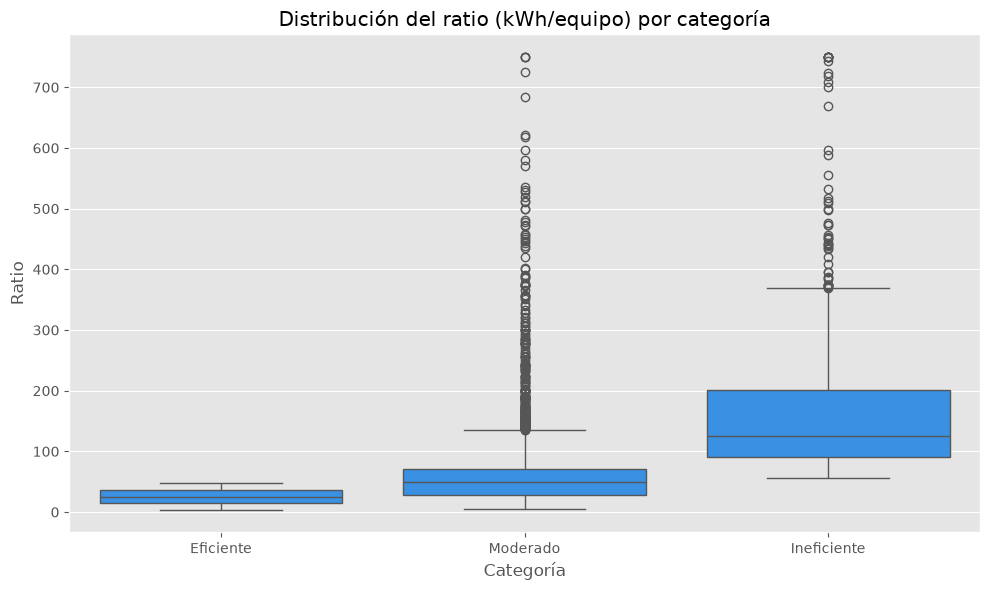

In [15]:
# Análisis del ratio (consumo/equipos) por categoría

# Calcular ratio
df_ext['ratio'] = df_ext['consumo_kwh'] / df_ext['cantidad_equipos']

print("Distribución del ratio (consumo/equipos) por categoría:")
print("-" * 55)
display(df_ext.groupby('categoria')['ratio'].describe())
print("\n")

# Boxplot del ratio por categoría
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_ext, x='categoria', y='ratio', 
            order=['Eficiente', 'Moderado', 'Ineficiente'], color='dodgerblue')
plt.title('Distribución del ratio (kWh/equipo) por categoría')
plt.ylabel('Ratio')
plt.xlabel('Categoría')
plt.tight_layout()
#plt.savefig(f'{OUTPUT_IMAGES_PATH}/ratio_por_categoria_extendido.png', dpi=150, bbox_inches='tight')
plt.show()

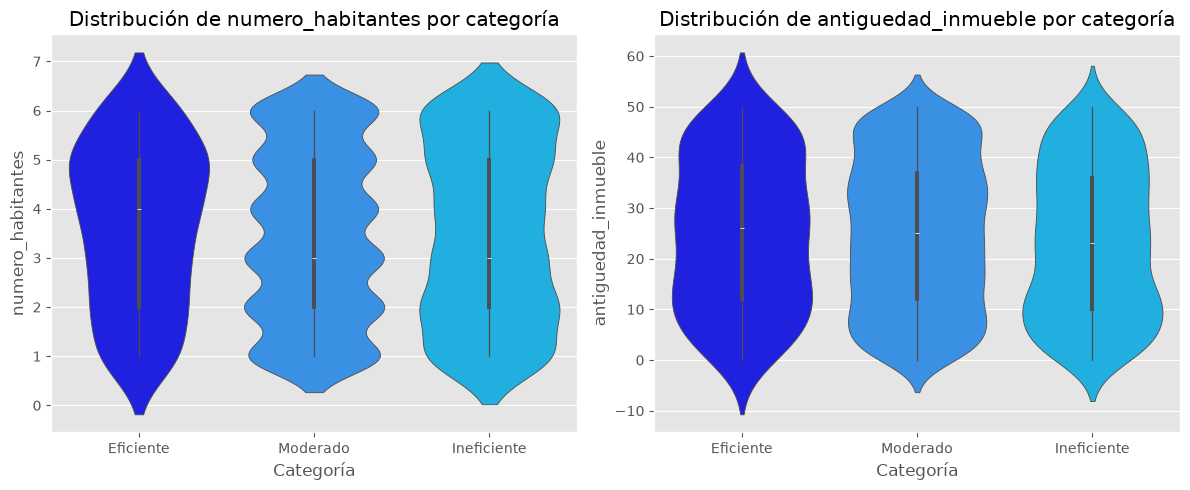

In [16]:
# Análisis de nuevas variables vs categoría

new_cols = ['numero_habitantes', 'antiguedad_inmueble']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for i, col in enumerate(new_cols):
    sns.violinplot(data=df_ext, x='categoria', y=col, ax=axes[i], 
                   order=['Eficiente', 'Moderado', 'Ineficiente'], palette=['blue', 'dodgerblue', 'deepskyblue'])
    axes[i].set_title(f'Distribución de {col} por categoría')
    axes[i].set_xlabel('Categoría')
    axes[i].set_ylabel(col)

plt.tight_layout()
#plt.savefig(f'{OUTPUT_IMAGES_PATH}/violin_nuevas_variables_extendido.png', dpi=150, bbox_inches='tight')
plt.show()

### 5. Evaluación de la lógica de clasificación mejorada

Ratio medio por categoría (con penalización ya aplicada):
------------------------------------------------------------
categoria
Eficiente       25.51
Ineficiente    172.47
Moderado        69.89
Name: ratio, dtype: float64

Ratio medio por categoría y presencia de calefacción:
-------------------------------------------------------
categoria    calefaccion
Eficiente    False           24.68
             True            27.29
Ineficiente  False          164.64
             True           185.80
Moderado     False           68.86
             True            71.75
Name: ratio, dtype: float64

Ratio medio por categoría y presencia de aire acondicionado:
------------------------------------------------------------
categoria    aire_acondicionado
Eficiente    False                  24.80
             True                   27.07
Ineficiente  False                 155.00
             True                  192.52
Moderado     False                  62.51
             True                   80

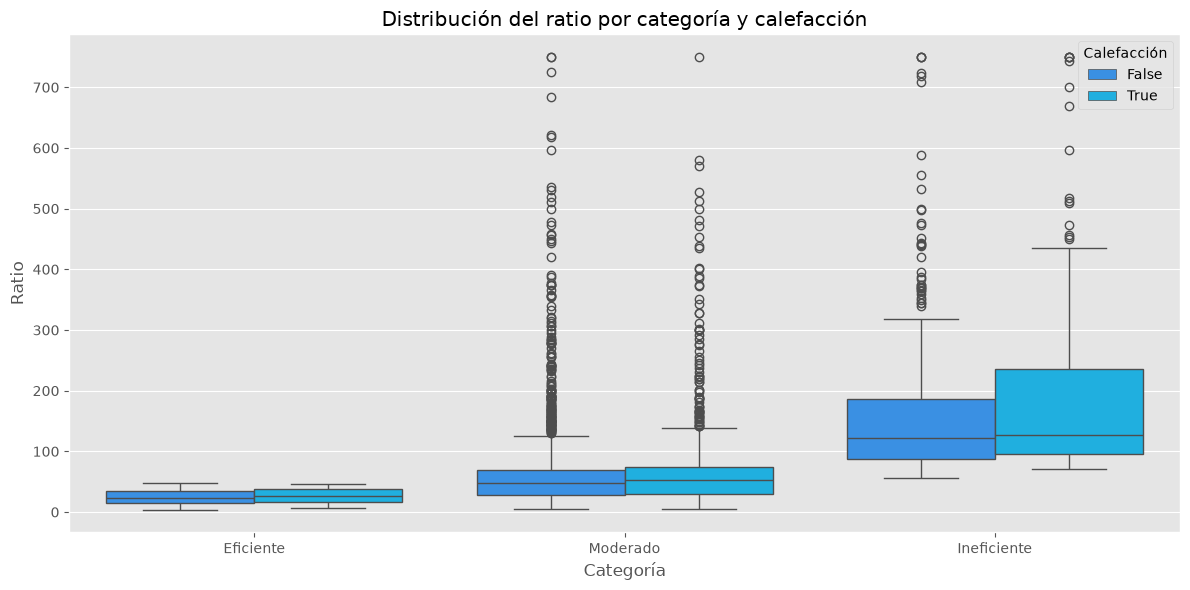

In [17]:
# Comparación de ratios por categoría con y sin penalización

print("Ratio medio por categoría (con penalización ya aplicada):")
print("-" * 60)
print(df_ext.groupby('categoria')['ratio'].mean().round(2))

# Analizar cómo influyen calefacción y aire acondicionado en el ratio por categoría
print("\nRatio medio por categoría y presencia de calefacción:")
print("-" * 55)
print(df_ext.groupby(['categoria', 'calefaccion'])['ratio'].mean().round(2))

print("\nRatio medio por categoría y presencia de aire acondicionado:")
print("-" * 60)
print(df_ext.groupby(['categoria', 'aire_acondicionado'])['ratio'].mean().round(2))

# Visualización: boxplots de ratio por categoría y calefacción
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_ext, x='categoria', y='ratio', hue='calefaccion', 
            order=['Eficiente', 'Moderado', 'Ineficiente'], palette=['dodgerblue', 'deepskyblue'])
plt.title('Distribución del ratio por categoría y calefacción')
plt.ylabel('Ratio')
plt.xlabel('Categoría')
plt.legend(title='Calefacción')
plt.tight_layout()
#plt.savefig(f'{OUTPUT_IMAGES_PATH}/ratio_categoria_calefaccion.png', dpi=150, bbox_inches='tight')
plt.show()

Tabla de contingencia: calefaccion vs categoria (proporciones por categoría)
--------------------------------------------------------------------------------


categoria,Eficiente,Ineficiente,Moderado
calefaccion,,,
False,0.681,0.63,0.642
True,0.319,0.37,0.358



Tabla de contingencia: aire_acondicionado vs categoria (proporciones por categoría)
-------------------------------------------------------------------------------------


categoria,Eficiente,Ineficiente,Moderado
aire_acondicionado,,,
False,0.688,0.534,0.598
True,0.312,0.466,0.402


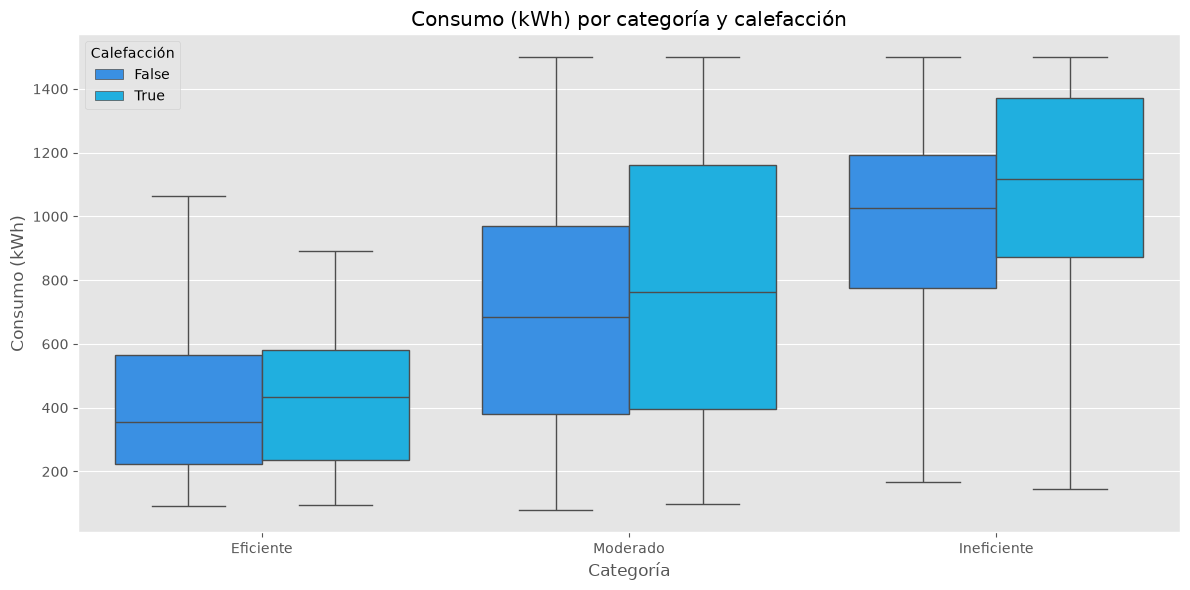

In [18]:
# Influencia de nuevas variables en la categoría

# Tabla de contingencia: calefaccion vs categoria (proporciones por columna)
print("Tabla de contingencia: calefaccion vs categoria (proporciones por categoría)")
print("-" * 80)
display(pd.crosstab(df_ext['calefaccion'], df_ext['categoria'], normalize='columns').round(3))

# Tabla de contingencia: aire_acondicionado vs categoria
print("\nTabla de contingencia: aire_acondicionado vs categoria (proporciones por categoría)")
print("-" * 85)
display(pd.crosstab(df_ext['aire_acondicionado'], df_ext['categoria'], normalize='columns').round(3))

# Boxplots de consumo por calefaccion y categoria
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_ext, x='categoria', y='consumo_kwh', hue='calefaccion', 
            order=['Eficiente', 'Moderado', 'Ineficiente'], palette=['dodgerblue', 'deepskyblue'])
plt.title('Consumo (kWh) por categoría y calefacción')
plt.ylabel('Consumo (kWh)')
plt.xlabel('Categoría')
plt.legend(title='Calefacción')
plt.tight_layout()
#plt.savefig(f'{OUTPUT_IMAGES_PATH}/consumo_categoria_calefaccion.png', dpi=150, bbox_inches='tight')
plt.show()

In [19]:
# Validación de la lógica de clasificación

# Recordemos la lógica:
# - Ineficiente: ratio > (55 + penalización) y horas_alto_consumo > 7
# - Eficiente: ratio < (28 + penalización) y horas_alto_consumo < 4
# - Moderado: resto

# Calcular penalización (simulada) para cada fila
penalizacion = np.zeros(len(df_ext))
penalizacion[df_ext['calefaccion']] += 5
penalizacion[df_ext['aire_acondicionado']] += 8

# Verificar si las reglas se cumplen
df_ext['penalizacion'] = penalizacion
df_ext['umbral_ineficiente'] = 55 + penalizacion
df_ext['umbral_eficiente'] = 28 + penalizacion

# Filas que cumplen las reglas
ineficiente_cumple = (df_ext['ratio'] > df_ext['umbral_ineficiente']) & (df_ext['horas_alto_consumo'] > 7)
eficiente_cumple = (df_ext['ratio'] < df_ext['umbral_eficiente']) & (df_ext['horas_alto_consumo'] < 4)

print("Validación de reglas de clasificación:")
print("-" * 40)
print(f"Filas con categoría Ineficiente que cumplen la regla: {ineficiente_cumple.sum()} / {len(df_ext[df_ext['categoria'] == 'Ineficiente'])}")
print(f"Filas con categoría Eficiente que cumplen la regla: {eficiente_cumple.sum()} / {len(df_ext[df_ext['categoria'] == 'Eficiente'])}")

# Mostrar ejemplos de filas que no cumplen (si las hay)
if not ineficiente_cumple.all():
    print("\nEjemplos de Ineficiente que NO cumplen la regla:")
    display(df_ext[(df_ext['categoria'] == 'Ineficiente') & (~ineficiente_cumple)].head())

if not eficiente_cumple.all():
    print("\nEjemplos de Eficiente que NO cumplen la regla:")
    display(df_ext[(df_ext['categoria'] == 'Eficiente') & (~eficiente_cumple)].head())

Validación de reglas de clasificación:
----------------------------------------
Filas con categoría Ineficiente que cumplen la regla: 790 / 638
Filas con categoría Eficiente que cumplen la regla: 103 / 160

Ejemplos de Ineficiente que NO cumplen la regla:


,consumo_kwh,cantidad_equipos,horas_alto_consumo,tipo_inmueble,uso_horario_pico,numero_habitantes,antiguedad_inmueble,calefaccion,aire_acondicionado,categoria,ratio,penalizacion,umbral_ineficiente,umbral_eficiente



Ejemplos de Eficiente que NO cumplen la regla:


,consumo_kwh,cantidad_equipos,horas_alto_consumo,tipo_inmueble,uso_horario_pico,numero_habitantes,antiguedad_inmueble,calefaccion,aire_acondicionado,categoria,ratio,penalizacion,umbral_ineficiente,umbral_eficiente
12,465,13,2,Local,True,1,11,False,False,Eficiente,35.769231,0.0,55.0,28.0
37,513,13,2,Oficina,False,2,13,False,True,Eficiente,39.461538,8.0,63.0,36.0
70,843,21,2,Oficina,True,2,43,False,False,Eficiente,40.142857,0.0,55.0,28.0
126,657,19,3,Local,False,5,11,False,False,Eficiente,34.578947,0.0,55.0,28.0
164,277,9,3,Apartamento,True,3,47,False,False,Eficiente,30.777778,0.0,55.0,28.0


### 6. Conclusiones y definición de variables

In [20]:
#  Resumen de hallazgos clave

print("Resumen de hallazgos del EDA del dataset extendido:")
print("-" * 52)

# 1. Principal diferenciador
print("1. El ratio 'consumo_kwh / cantidad_equipos' es el principal diferenciador entre categorías:")
print(f"   - Eficiente: media {df_ext[df_ext['categoria']=='Eficiente']['ratio'].mean():.2f}")
print(f"   - Moderado:  media {df_ext[df_ext['categoria']=='Moderado']['ratio'].mean():.2f}")
print(f"   - Ineficiente: media {df_ext[df_ext['categoria']=='Ineficiente']['ratio'].mean():.2f}")

# 2. Influencia de calefacción y aire acondicionado
print("\n2. Calefacción y aire acondicionado elevan el ratio y la probabilidad de ser Ineficiente:")
print(f"   - Proporción de Ineficiente con calefacción: {df_ext[(df_ext['categoria']=='Ineficiente') & (df_ext['calefaccion'])].shape[0] / df_ext[df_ext['categoria']=='Ineficiente'].shape[0]:.2%}")
print(f"   - Proporción de Ineficiente con aire acondicionado: {df_ext[(df_ext['categoria']=='Ineficiente') & (df_ext['aire_acondicionado'])].shape[0] / df_ext[df_ext['categoria']=='Ineficiente'].shape[0]:.2%}")

# 3. Otras variables
print("\n3. Otras variables (numero_habitantes, antiguedad_inmueble) no discriminan fuertemente por sí solas, pero pueden aportar en interacciones.")
print("4. Existe solapamiento entre categorías (especialmente en los límites de los umbrales), lo cual es esperable en problemas de clasificación reales.")

Resumen de hallazgos del EDA del dataset extendido:
----------------------------------------------------
1. El ratio 'consumo_kwh / cantidad_equipos' es el principal diferenciador entre categorías:
   - Eficiente: media 25.51
   - Moderado:  media 69.89
   - Ineficiente: media 172.47

2. Calefacción y aire acondicionado elevan el ratio y la probabilidad de ser Ineficiente:
   - Proporción de Ineficiente con calefacción: 36.99%
   - Proporción de Ineficiente con aire acondicionado: 46.55%

3. Otras variables (numero_habitantes, antiguedad_inmueble) no discriminan fuertemente por sí solas, pero pueden aportar en interacciones.
4. Existe solapamiento entre categorías (especialmente en los límites de los umbrales), lo cual es esperable en problemas de clasificación reales.


In [21]:
# Definición de variables para el modelo

print("\nDefinición de variables para el modelo:")
print("-" * 50)

# Variables de entrada (features)
features = ['consumo_kwh', 'cantidad_equipos', 'horas_alto_consumo', 
            'tipo_inmueble', 'uso_horario_pico', 'numero_habitantes', 
            'antiguedad_inmueble', 'calefaccion', 'aire_acondicionado']

# Variable objetivo (target)
target = 'categoria'

print(f"Variables de entrada ({len(features)}): {', '.join(features)}")
print(f"Variable objetivo: {target}")

# Justificación
print("\nJustificación:")
print("- Se mantienen todas las variables porque, aunque algunas no discriminen individualmente, pueden tener interacciones relevantes.")
print("- El modelo de Machine Learning podrá aprender combinaciones no lineales.")
print("- Se recomienda no eliminar variables sin un análisis de importancia posterior al entrenamiento.")


Definición de variables para el modelo:
--------------------------------------------------
Variables de entrada (9): consumo_kwh, cantidad_equipos, horas_alto_consumo, tipo_inmueble, uso_horario_pico, numero_habitantes, antiguedad_inmueble, calefaccion, aire_acondicionado
Variable objetivo: categoria

Justificación:
- Se mantienen todas las variables porque, aunque algunas no discriminen individualmente, pueden tener interacciones relevantes.
- El modelo de Machine Learning podrá aprender combinaciones no lineales.
- Se recomienda no eliminar variables sin un análisis de importancia posterior al entrenamiento.


In [22]:
# Recomendaciones para la siguiente fase

print("\nRecomendaciones para la siguiente fase (entrenamiento de modelos):")
print("-" * 68)
print("1. Usar el dataset extendido ('dataset_extendido.csv') para entrenar modelos.")
print("2. Probar varios algoritmos: Regresión Logística, Árbol de Decisión, Random Forest, XGBoost.")
print("3. Evaluar con métricas adecuadas (F1-score, precisión/recall por clase) debido al desbalanceo.")
print("4. Considerar técnicas de balanceo (SMOTE, class_weight) si el desbalanceo afecta el rendimiento.")
print("5. Realizar validación cruzada para evaluar la generalización.")
print("6. Guardar el modelo final en formato .pkl para su uso en la API.")


Recomendaciones para la siguiente fase (entrenamiento de modelos):
--------------------------------------------------------------------
1. Usar el dataset extendido ('dataset_extendido.csv') para entrenar modelos.
2. Probar varios algoritmos: Regresión Logística, Árbol de Decisión, Random Forest, XGBoost.
3. Evaluar con métricas adecuadas (F1-score, precisión/recall por clase) debido al desbalanceo.
4. Considerar técnicas de balanceo (SMOTE, class_weight) si el desbalanceo afecta el rendimiento.
5. Realizar validación cruzada para evaluar la generalización.
6. Guardar el modelo final en formato .pkl para su uso en la API.
